# Improving Numerical Determinism in LLM Inference using TinyLlama

## MSc Deep Learning

In [1]:
# ==========================================================
# MSc Deep Learning
# Numerical Determinism in LLM Inference
# Collins Collins
# ==========================================================

## 1. Environment Setup

In [2]:
# Install required libraries

!pip -q install transformers accelerate sentencepiece datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [3]:
import torch
import transformers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("="*60)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
CUDA: True
GPU: Tesla T4


## 2. Load TinyLlama Model

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

print("Model loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Loading model...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully!


## 3. Baseline Inference

In [5]:
# Define the prompt

prompt = """
Explain numerical determinism in deep learning in simple terms.
"""

In [6]:
print(prompt)


Explain numerical determinism in deep learning in simple terms.



In [7]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

print(inputs.keys())
print(inputs["input_ids"].shape)

KeysView({'input_ids': tensor([[    1, 29871,    13,  9544,  7420, 16259, 11806,  1608,   297,  6483,
          6509,   297,  2560,  4958, 29889,    13]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')})
torch.Size([1, 16])


In [8]:
import time

start_time = time.time()

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False
    )

end_time = time.time()

response = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print(response)


Explain numerical determinism in deep learning in simple terms.

Numerical determinism is a fundamental principle in deep learning that states that the output of a neural network is determined by the input data. This principle is based on the fact that the weights of the neural network are determined by the training data, and the output of the network is a function of the input data.

In deep learning, the input data is typically represented as a matrix or tensor, which is a collection of elements that are arranged in a specific way. The weights of the neural network are then learned by minimizing a loss function that measures the difference between the output of the network and the true output.

The output of the network is determined by the weights of the network, which are optimized using backpropagation


In [9]:
latency = end_time - start_time

print(f"Inference Time: {latency:.3f} seconds")

Inference Time: 7.359 seconds


In [10]:
memory = torch.cuda.max_memory_allocated() / 1024**2

print(f"GPU Memory Used: {memory:.2f} MB")

GPU Memory Used: 979.19 MB


In [11]:
import pandas as pd

baseline_results = pd.DataFrame({
    "Prompt": [prompt],
    "Inference_Time": [latency],
    "GPU_Memory_MB": [memory],
    "Response": [response]
})

baseline_results

,Prompt,Inference_Time,GPU_Memory_MB,Response
0,\nExplain numerical determinism in deep learni...,7.359206,979.187012,\nExplain numerical determinism in deep learni...


In [12]:
baseline_results.to_csv(
    "baseline_results.csv",
    index=False
)

print("Baseline results saved successfully.")

Baseline results saved successfully.


## 4. Determinism Evaluation

In [13]:
results = []

for i in range(5):

    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False
        )

    end = time.time()

    text = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    results.append({
        "Run": i + 1,
        "Inference_Time_sec": round(end - start, 3),
        "Response": text
    })

print("Experiment completed!")

Experiment completed!


In [14]:
experiment_df = pd.DataFrame(results)

experiment_df

,Run,Inference_Time_sec,Response
0,1,6.096,\nExplain numerical determinism in deep learni...
1,2,6.243,\nExplain numerical determinism in deep learni...
2,3,6.232,\nExplain numerical determinism in deep learni...
3,4,6.275,\nExplain numerical determinism in deep learni...
4,5,6.232,\nExplain numerical determinism in deep learni...


In [15]:
for i, text in enumerate(experiment_df["Response"], start=1):
    print("=" * 60)
    print(f"RUN {i}")
    print("=" * 60)
    print(text)
    print()

RUN 1

Explain numerical determinism in deep learning in simple terms.

Numerical determinism is a fundamental principle in deep learning that states that the output of a neural network is determined by the input data. This principle is based on the fact that the weights of the neural network are determined by the training data, and the output of the network is a function of the input data.

In deep learning, the input data is typically represented as a matrix or tensor, which is a collection of elements that are arranged in a specific way. The weights of the neural network are then learned by minimizing a loss function that measures the difference between the output of the network and the true output.

The output of the network is determined by the weights of the network, which are optimized using backpropagation

RUN 2

Explain numerical determinism in deep learning in simple terms.

Numerical determinism is a fundamental principle in deep learning that states that the output of a ne

In [16]:
unique_outputs = experiment_df["Response"].nunique()

print(f"Unique Responses: {unique_outputs}")

if unique_outputs == 1:
    print("✅ All responses are identical (Deterministic)")
else:
    print("❌ Responses differ (Non-deterministic)")

Unique Responses: 1
✅ All responses are identical (Deterministic)


In [17]:
def evaluate_model(model, tokenizer, prompt, runs=5):

    import pandas as pd
    import time
    import torch

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    results = []

    for i in range(runs):

        torch.cuda.reset_peak_memory_stats()

        start = time.time()

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False
            )

        end = time.time()

        response = tokenizer.decode(
            output[0],
            skip_special_tokens=True
        )

        memory = torch.cuda.max_memory_allocated() / (1024**2)

        results.append({
            "Run": i + 1,
            "Inference_Time_sec": round(end - start, 3),
            "GPU_Memory_MB": round(memory, 2),
            "Response": response
        })

    return pd.DataFrame(results)

In [18]:
results_df = evaluate_model(
    model=model,
    tokenizer=tokenizer,
    prompt=prompt,
    runs=5
)

results_df

,Run,Inference_Time_sec,GPU_Memory_MB,Response
0,1,5.847,979.19,\nExplain numerical determinism in deep learni...
1,2,5.610,979.19,\nExplain numerical determinism in deep learni...
2,3,5.663,979.19,\nExplain numerical determinism in deep learni...
3,4,5.550,979.19,\nExplain numerical determinism in deep learni...
4,5,5.557,979.19,\nExplain numerical determinism in deep learni...


In [19]:
results_df.describe()

,Run,Inference_Time_sec,GPU_Memory_MB
count,5.000000,5.000000,5.000000e+00
mean,3.000000,5.645400,9.791900e+02
std,1.581139,0.121574,1.271057e-13
min,1.000000,5.550000,9.791900e+02
25%,2.000000,5.557000,9.791900e+02
50%,3.000000,5.610000,9.791900e+02
75%,4.000000,5.663000,9.791900e+02
max,5.000000,5.847000,9.791900e+02


In [20]:
print("Unique Responses:", results_df["Response"].nunique())

if results_df["Response"].nunique() == 1:
    print("✅ Deterministic Output")
else:
    print("❌ Non-Deterministic Output")

Unique Responses: 1
✅ Deterministic Output


In [21]:
results_df.to_csv("baseline_experiment.csv", index=False)

print("Baseline Experiment Saved")

Baseline Experiment Saved


In [22]:
average_time = results_df["Inference_Time_sec"].mean()
average_memory = results_df["GPU_Memory_MB"].mean()

print(f"Average Inference Time : {average_time:.3f} sec")
print(f"Average GPU Memory     : {average_memory:.2f} MB")

Average Inference Time : 5.645 sec
Average GPU Memory     : 979.19 MB


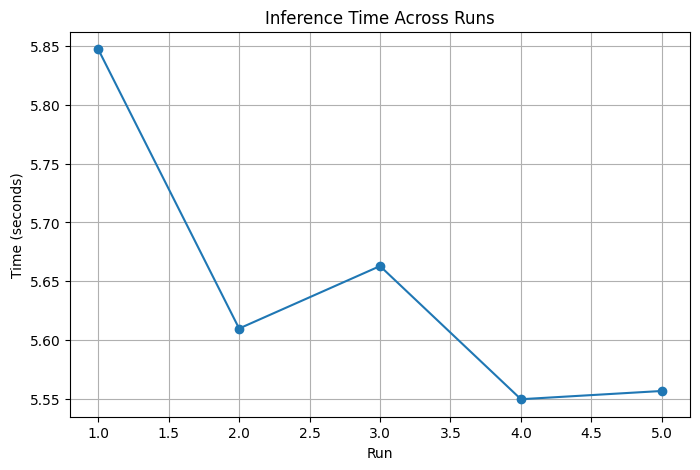

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df["Run"],
    results_df["Inference_Time_sec"],
    marker="o"
)

plt.title("Inference Time Across Runs")
plt.xlabel("Run")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.show()

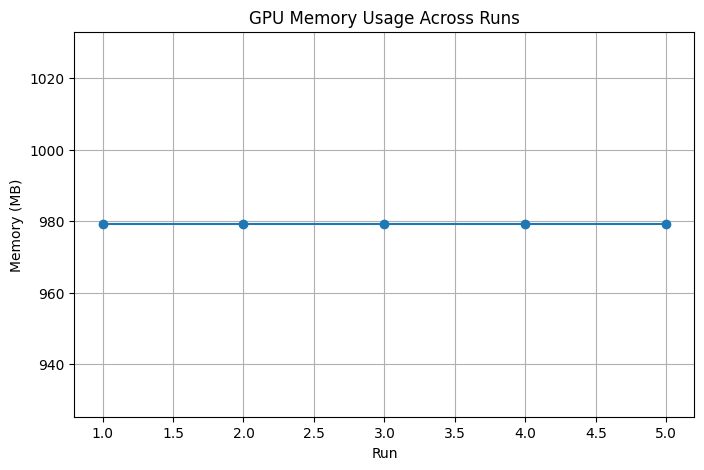

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Run"],
    results_df["GPU_Memory_MB"],
    marker="o"
)

plt.title("GPU Memory Usage Across Runs")
plt.xlabel("Run")
plt.ylabel("Memory (MB)")
plt.grid(True)

plt.show()

In [25]:
results_df.to_excel(
    "Baseline_Results.xlsx",
    index=False
)

print("Excel file created successfully.")

Excel file created successfully.


## 5. Precision Evaluation

In [26]:
PROMPTS = [
    "Explain Artificial Intelligence in simple terms.",
    "What is Machine Learning?",
    "Explain Deep Learning in simple terms.",
    "What is Numerical Determinism in deep learning?",
    "Explain Reinforcement Learning with a simple example."
]

precision_results = []

model.eval()

for i, prompt in enumerate(PROMPTS, start=1):

    print("=" * 80)
    print(f"Running Prompt {i}/{len(PROMPTS)}")
    print(prompt)

    # Tokenize input
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    # Reset GPU statistics
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()

    # Deterministic inference
    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=120,
            min_new_tokens=40,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None,
            repetition_penalty=1.0,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    end_time = time.time()

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    inference_time = round(end_time - start_time, 3)

    if torch.cuda.is_available():
        gpu_memory = round(
            torch.cuda.max_memory_allocated() / (1024 ** 2),
            2
        )
    else:
        gpu_memory = 0

    precision_results.append({

        "Prompt": prompt,

        "Inference_Time_sec": inference_time,

        "GPU_Memory_MB": gpu_memory,

        "Response_Length": len(response),

        "Response": response

    })

precision_df = pd.DataFrame(precision_results)

print("\n")
print("=" * 80)
print("Precision Evaluation Completed Successfully")
print("=" * 80)

precision_df

Running Prompt 1/5
Explain Artificial Intelligence in simple terms.
Running Prompt 2/5
What is Machine Learning?
Running Prompt 3/5
Explain Deep Learning in simple terms.
Running Prompt 4/5
What is Numerical Determinism in deep learning?
Running Prompt 5/5
Explain Reinforcement Learning with a simple example.


Precision Evaluation Completed Successfully


,Prompt,Inference_Time_sec,GPU_Memory_MB,Response_Length,Response
0,Explain Artificial Intelligence in simple terms.,4.467,978.11,640,Explain Artificial Intelligence in simple term...
1,What is Machine Learning?,4.548,977.90,650,What is Machine Learning?\nMachine learning is...
2,Explain Deep Learning in simple terms.,4.475,978.00,607,Explain Deep Learning in simple terms. How doe...
3,What is Numerical Determinism in deep learning?,2.175,975.99,288,What is Numerical Determinism in deep learning...
4,Explain Reinforcement Learning with a simple e...,4.525,978.11,600,Explain Reinforcement Learning with a simple e...


In [27]:
precision_df.to_csv(
    "precision_evaluation.csv",
    index=False
)

precision_df.to_excel(
    "precision_evaluation.xlsx",
    index=False
)

print("Precision evaluation completed.")

Precision evaluation completed.


## 6. Precision Evaluation Summary

In [28]:
# ==========================================================
# Precision Evaluation Summary
# ==========================================================

summary = pd.DataFrame({

    "Metric": [
        "Average Inference Time (sec)",
        "Minimum Inference Time (sec)",
        "Maximum Inference Time (sec)",
        "Average GPU Memory (MB)",
        "Minimum GPU Memory (MB)",
        "Maximum GPU Memory (MB)",
        "Average Response Length"
    ],

    "Value": [

        round(precision_df["Inference_Time_sec"].mean(),3),

        round(precision_df["Inference_Time_sec"].min(),3),

        round(precision_df["Inference_Time_sec"].max(),3),

        round(precision_df["GPU_Memory_MB"].mean(),2),

        round(precision_df["GPU_Memory_MB"].min(),2),

        round(precision_df["GPU_Memory_MB"].max(),2),

        round(precision_df["Response_Length"].mean(),0)

    ]

})

summary

,Metric,Value
0,Average Inference Time (sec),4.038
1,Minimum Inference Time (sec),2.175
2,Maximum Inference Time (sec),4.548
3,Average GPU Memory (MB),977.620
4,Minimum GPU Memory (MB),975.990
5,Maximum GPU Memory (MB),978.110
6,Average Response Length,557.000


## 7. Visualisation

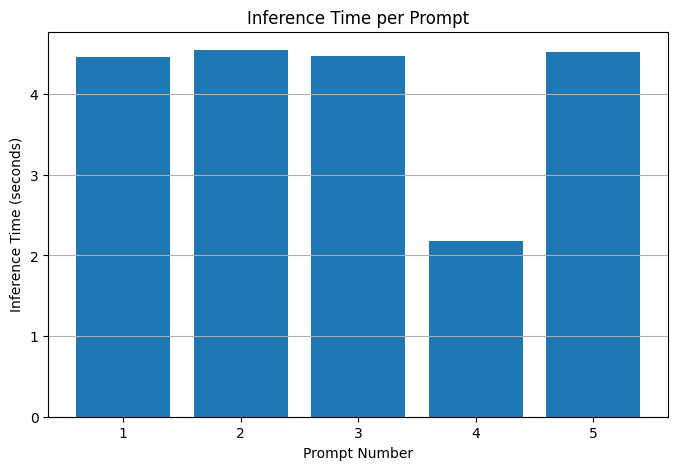

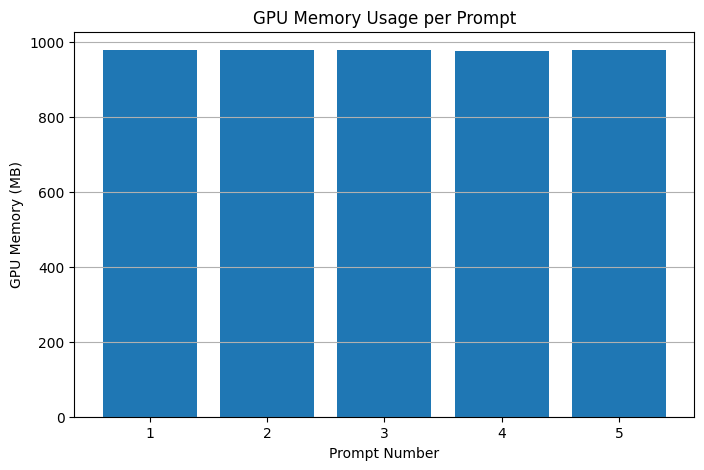

In [29]:
# ==========================================================
# Precision Evaluation Charts
# ==========================================================

plt.figure(figsize=(8,5))
plt.bar(range(len(precision_df)), precision_df["Inference_Time_sec"])
plt.xticks(range(len(precision_df)), range(1, len(precision_df)+1))
plt.xlabel("Prompt Number")
plt.ylabel("Inference Time (seconds)")
plt.title("Inference Time per Prompt")
plt.grid(axis="y")
plt.show()


plt.figure(figsize=(8,5))
plt.bar(range(len(precision_df)), precision_df["GPU_Memory_MB"])
plt.xticks(range(len(precision_df)), range(1, len(precision_df)+1))
plt.xlabel("Prompt Number")
plt.ylabel("GPU Memory (MB)")
plt.title("GPU Memory Usage per Prompt")
plt.grid(axis="y")
plt.show()

## 8. Export Results

In [30]:
summary.to_csv("precision_summary.csv", index=False)
summary.to_excel("precision_summary.xlsx", index=False)

print("Summary saved successfully.")

Summary saved successfully.
